# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
sys.path.insert(
    0,
    '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/'
)
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTHOGONALOS'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE = 'WUBIND'  # test_score, train_score, err
C_RITERION = ''
SEARCH_MODE = ''
TARGET = 'V0'
MOMENTS = 15

# Helpeer Functions 

In [3]:
from Tools import CaseNamer

In [4]:
FileNames = CaseNamer(CASE, MODEL,CUTOFF=CUT_OFF, EMODE=E_MODE,CRITERION=C_RITERION,SEARCHMODE = SEARCH_MODE)

In [5]:
from Tools import Plotting

# Load Features

## Load briefsummary and its features

In [6]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [7]:
BOPCOEF_FILE = 'CRCOW_{}_NSC_{}_{}_{}_{}.pkl'.format(CASE,MODEL,CUT_OFF,E_MODE, MOMENTS)
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
#BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

In [8]:
BopfoxFeatures.columns

Index(['NSC_U_bind', 'NSC_U_bond_atom', 'NSC_U_bond_atom_list', 'NSC_moments',
       'NSC_an', 'NSC_bn', 'NSC_SIGMA', 'NSC_Ainf', 'NSC_Binf'],
      dtype='object')

## clean features: reduntandly convert all features to float and mean across sites

In [9]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'], M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [10]:
allcolumns = BOP.columns

In [11]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [12]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [13]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [14]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [15]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [16]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

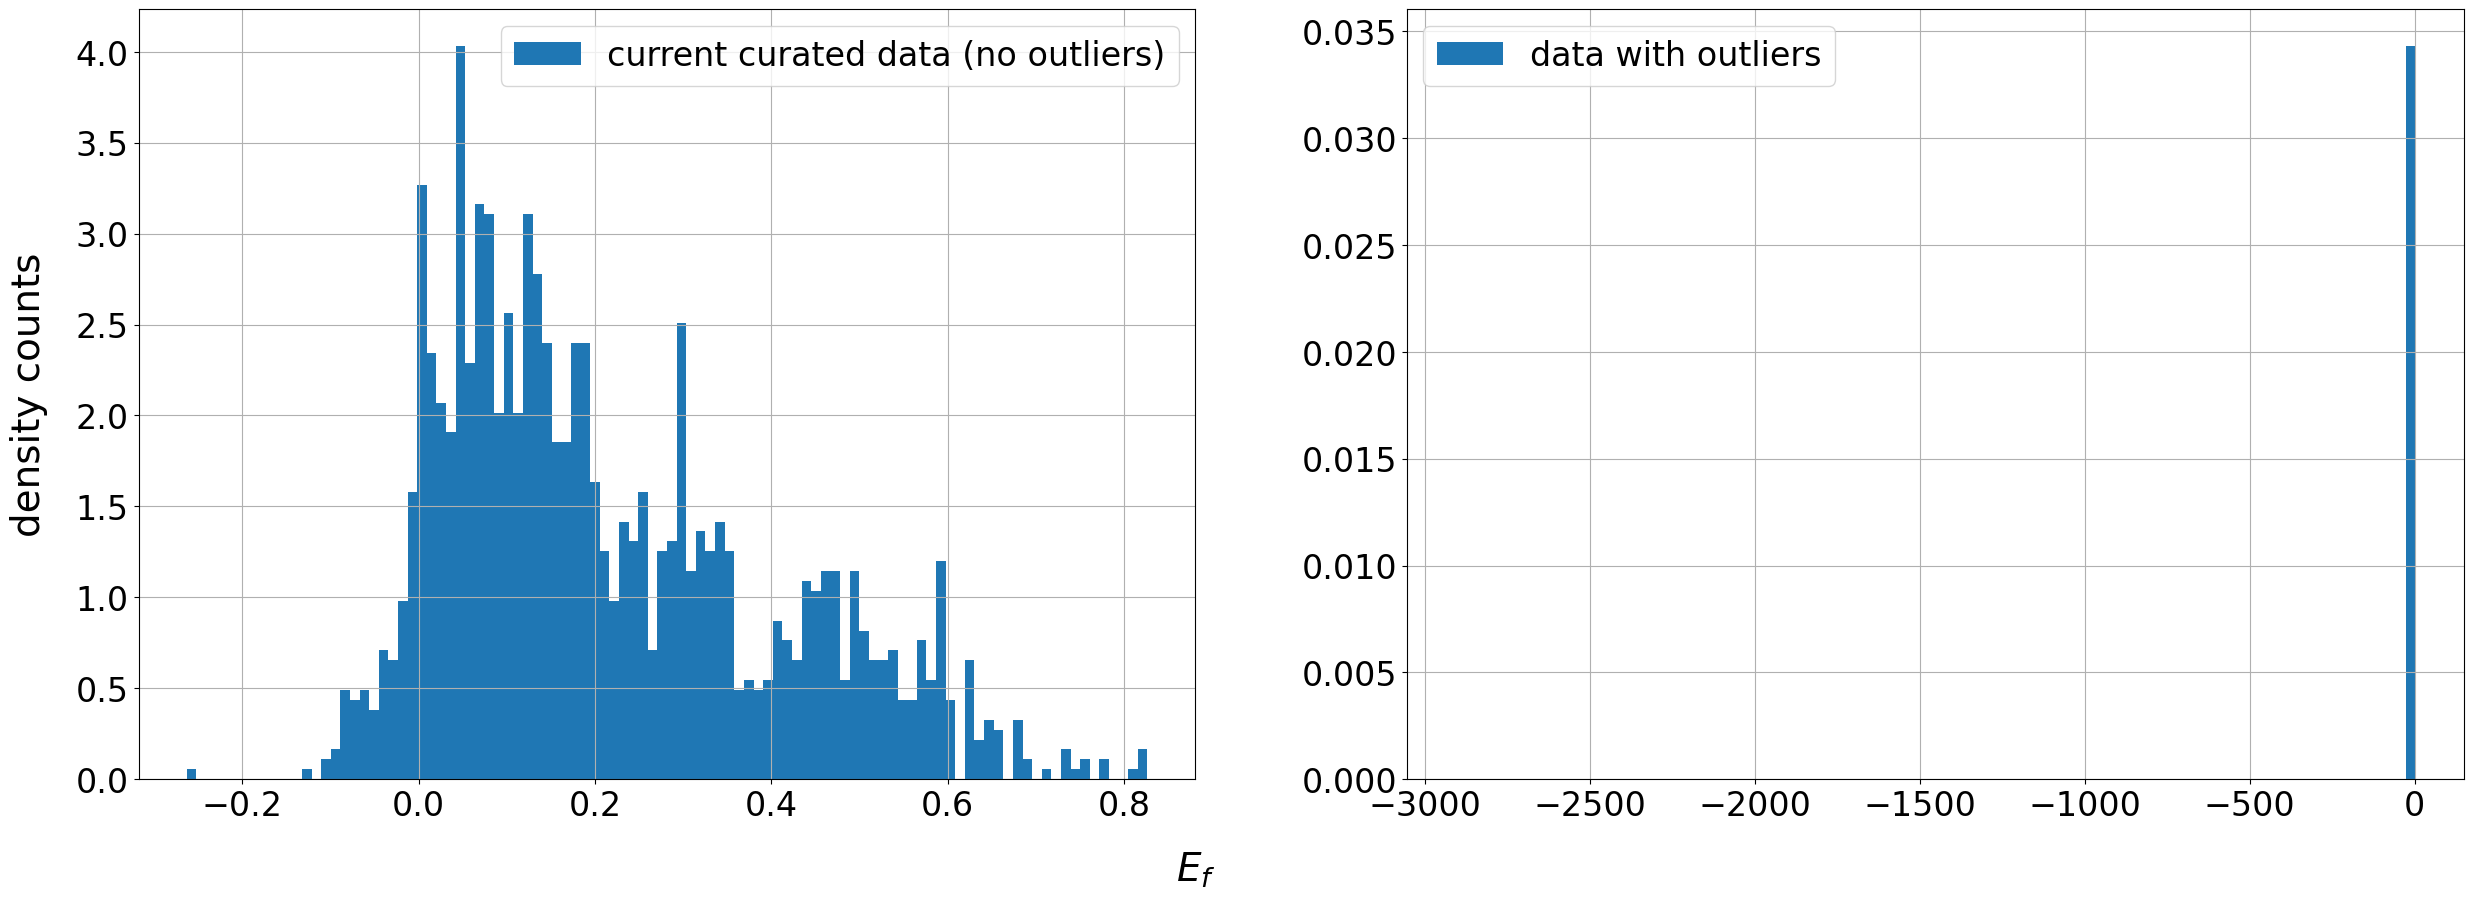

In [17]:
fig = Plotting.with_and_without_outliers(DATA['EF'],low=-1, hig=2.0)

In [18]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [19]:
Out_In_First

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_13,NSC_bn_14,NSC_bn_15,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv11W_sv2.mu-AAAAB.NM,-127.270287,-4.062308,22.658469,-149.575954,1080.533385,-8233.793846,64997.600000,-5.262885e+05,4.344585e+06,-3.641815e+07,...,0.0,0.0,0.0,-4.623779,2.894029,0.0,1013.263491,797.261714,-2908.966186,-2918.897693
Co_pv8W_sv4.C14-BAA.FM,-96.791626,-5.400000,36.218025,-280.001333,2430.730000,-23158.121667,237795.700000,-2.593840e+06,2.971803e+07,-3.544617e+08,...,0.0,0.0,0.0,-6.525821,5.143694,2.0,-3.039032,347.454241,3.087797,-5.877353
Cr_pv10Co_pv4W_sv16.sigma-ABCCA.FM,-396.730684,-4.938000,36.577613,-324.140733,3158.499333,-32596.586667,349537.493333,-3.851965e+06,4.332773e+07,-4.951796e+08,...,0.0,0.0,0.0,-5.897557,4.231375,2.0,-0.754852,780.349477,2.390903,-8.574481


In [20]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

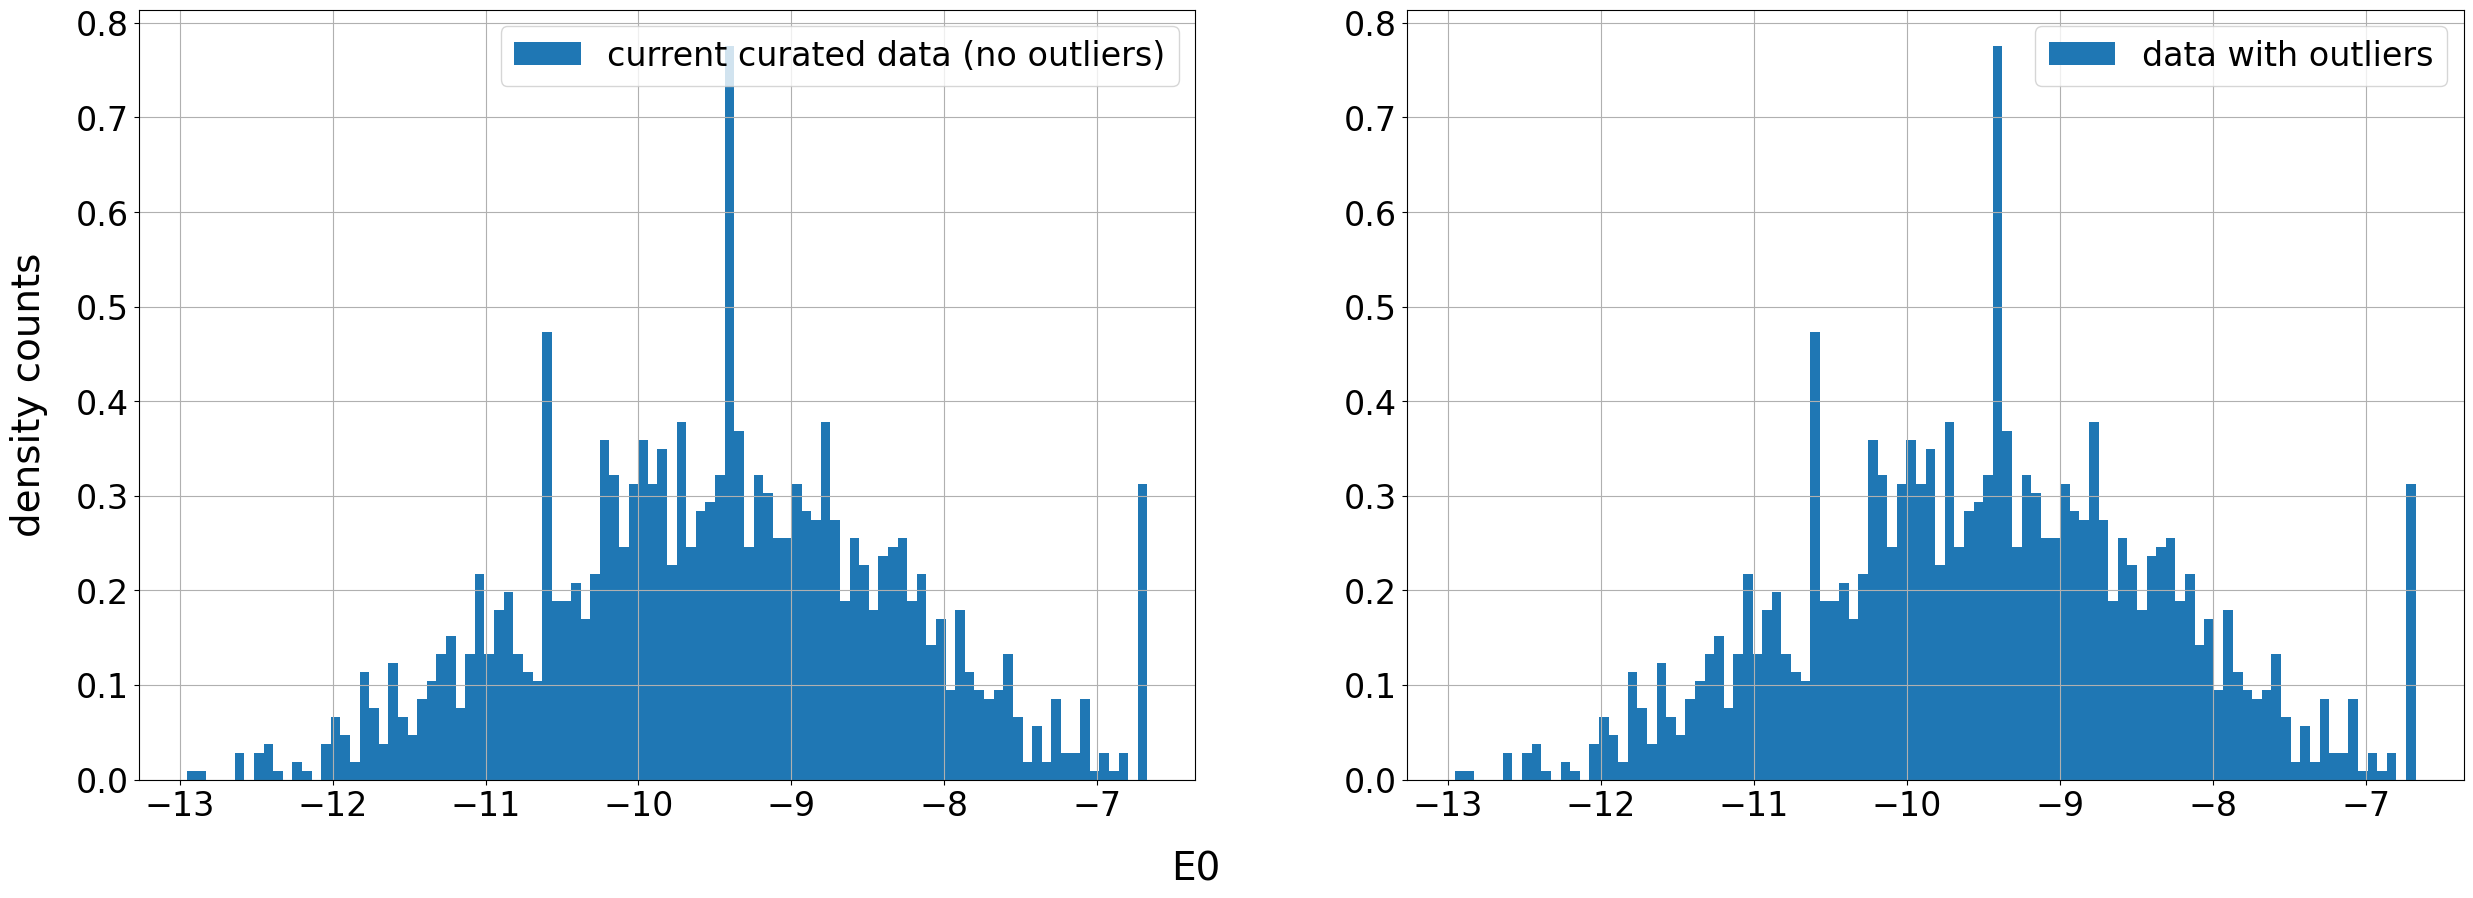

In [21]:
fige0 = Plotting.with_and_without_outliers(DATA['E0'],low=-100, hig=10, title='E0')

In [22]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [23]:
DATA.shape

(1684, 70)

### $E_0$ vs $\Delta E_{F}$

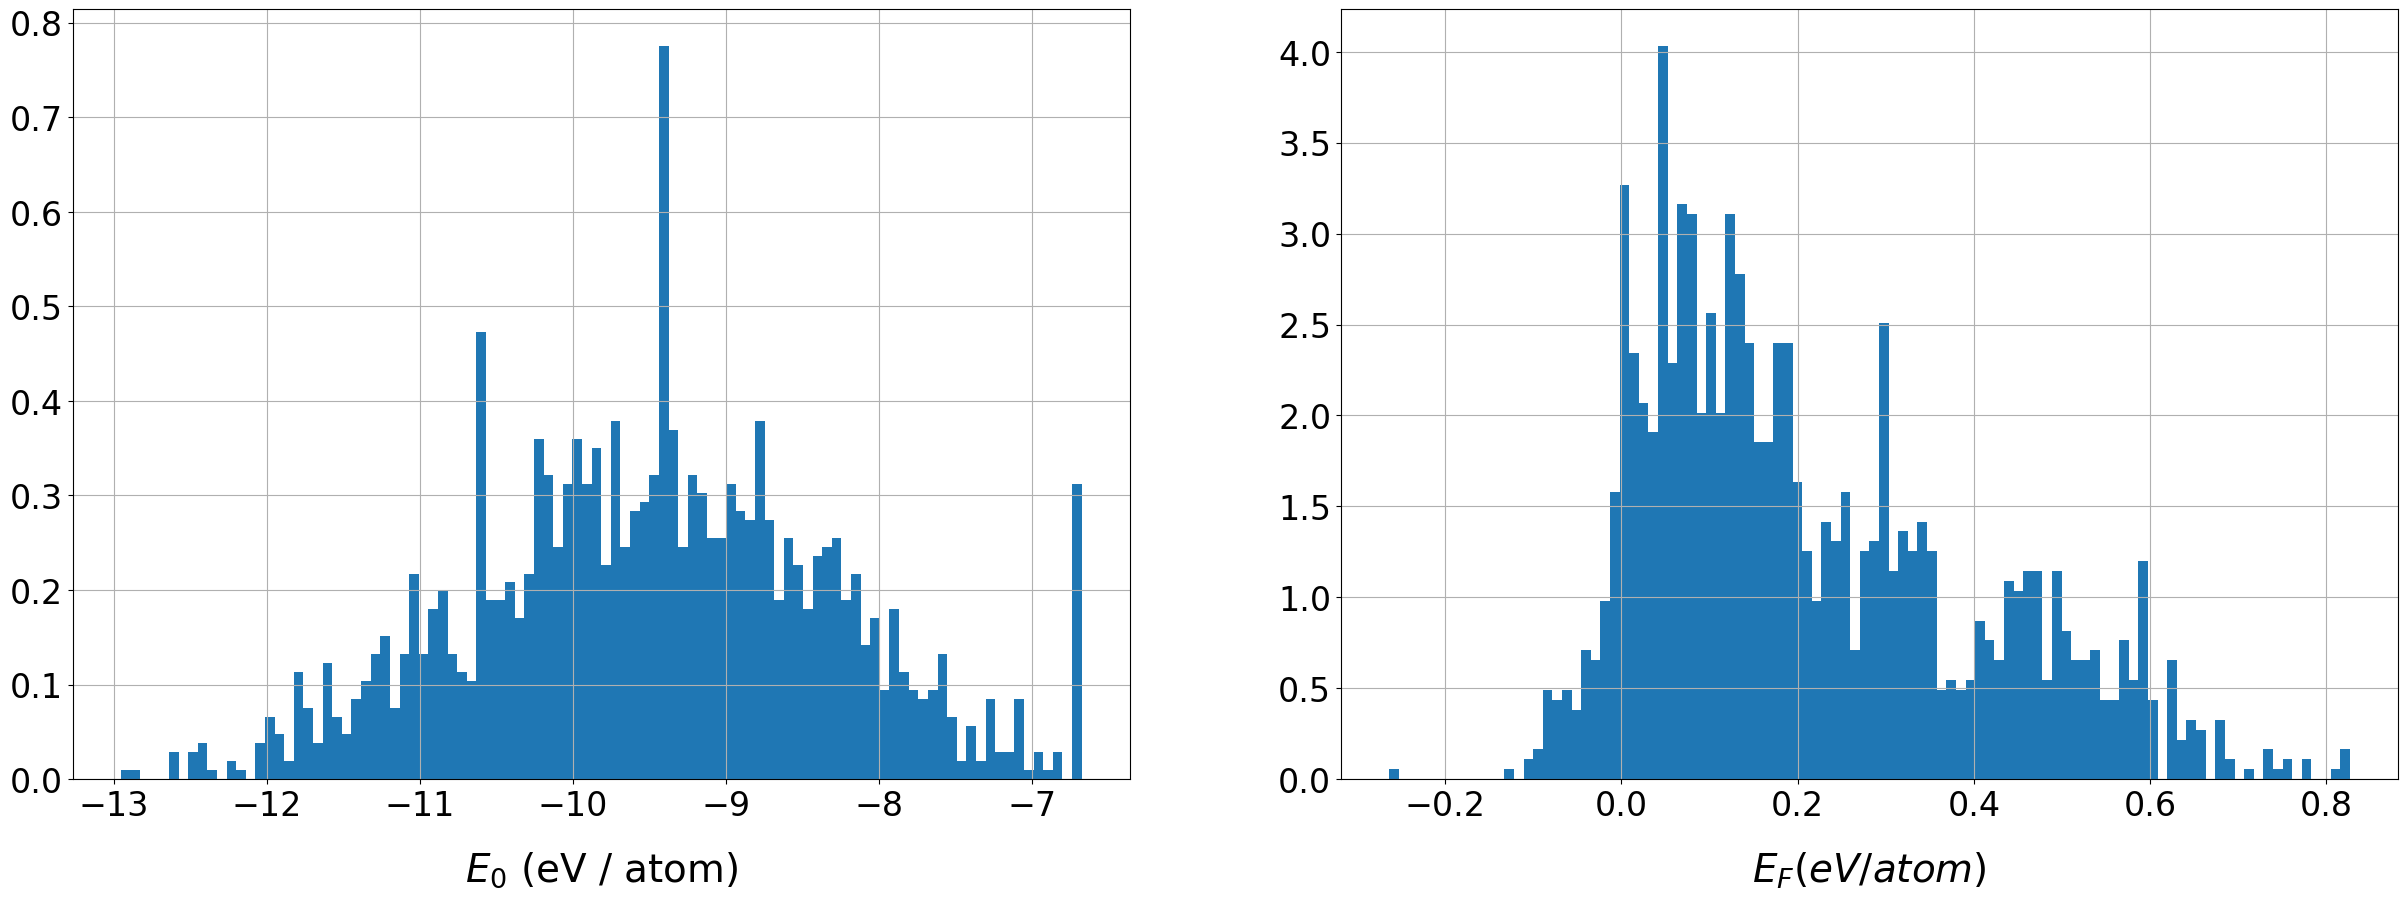

In [24]:
figcomp = Plotting.compare_features(DATA['EF'],'$E_{F} (eV / atom)$', DATA['E0'],'$E_{0}$ (eV / atom)')

## B0

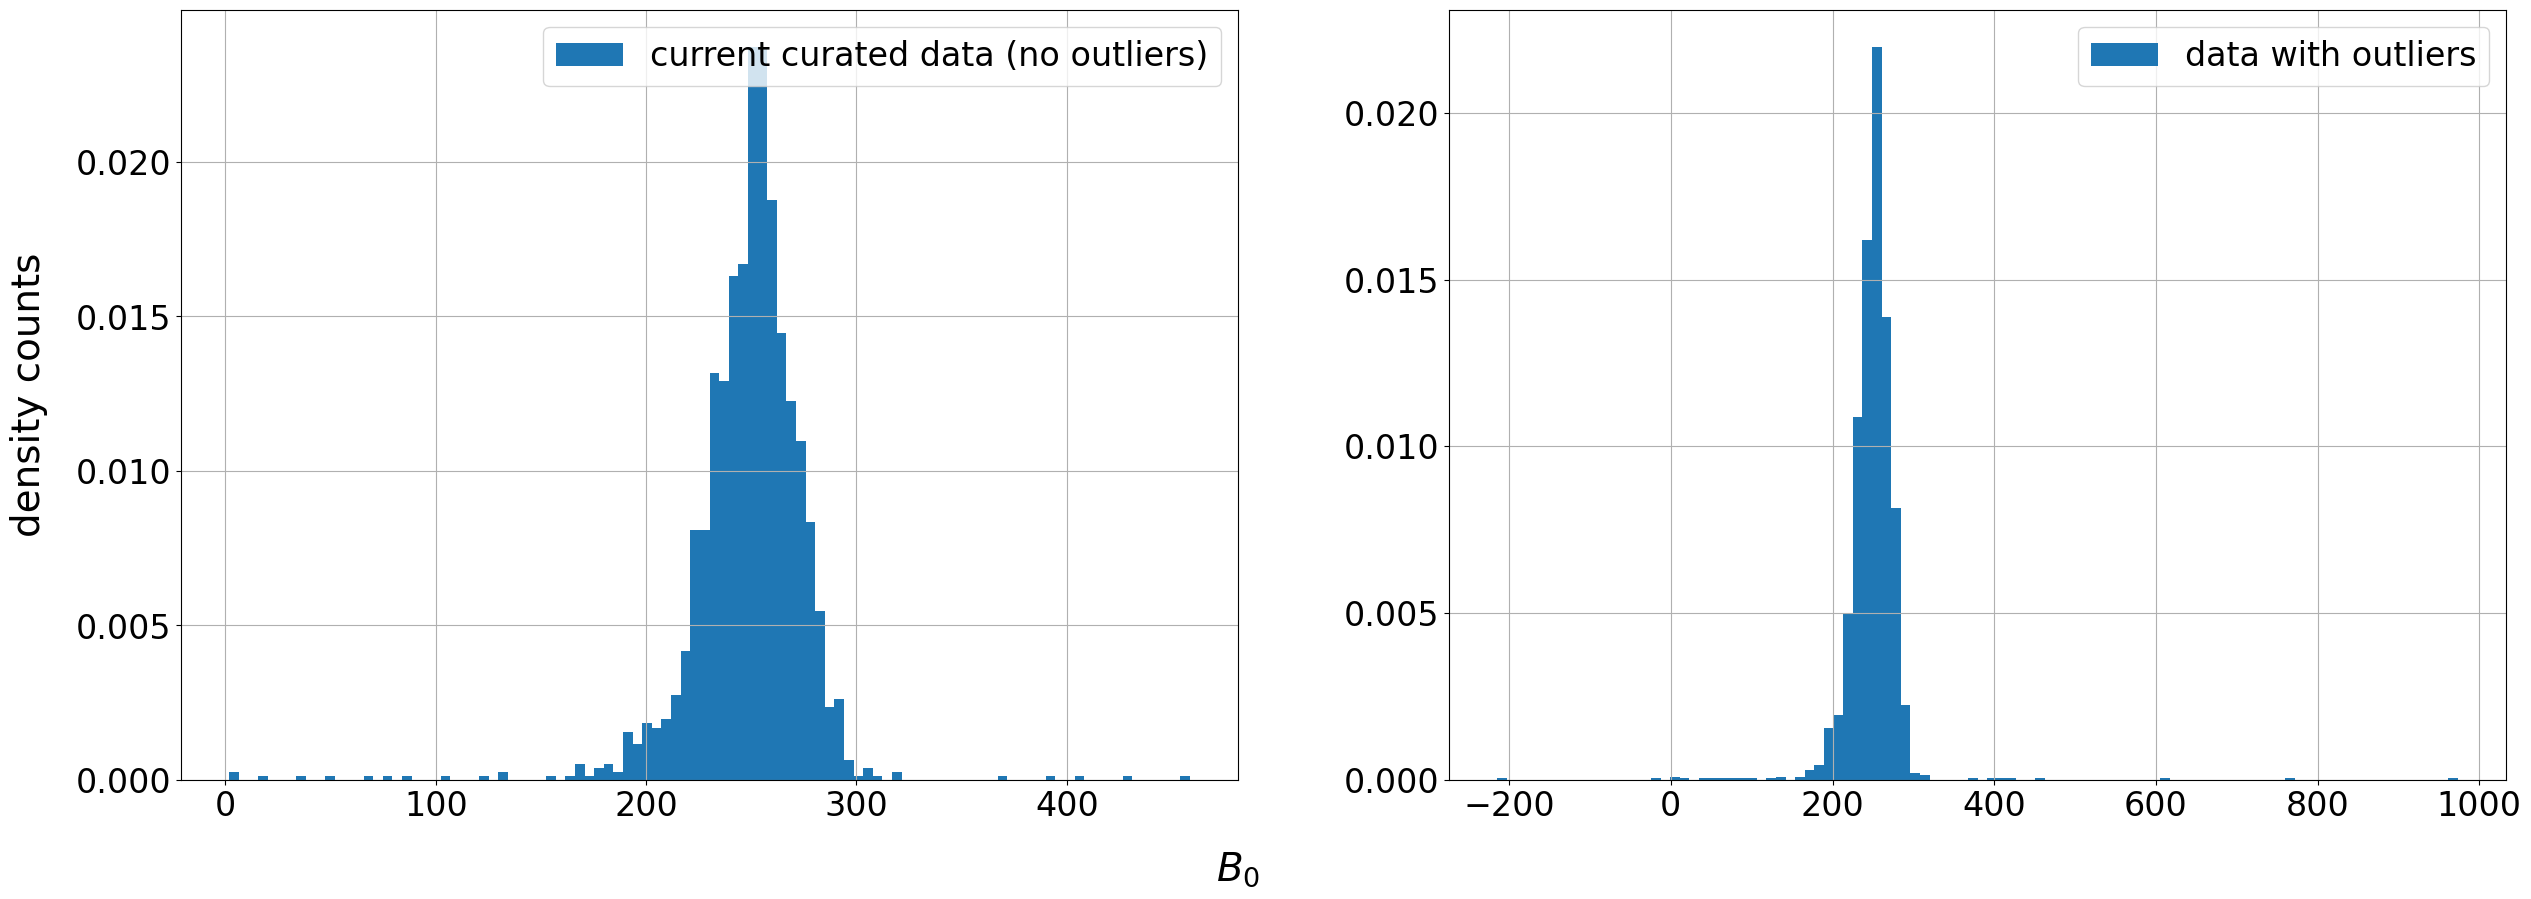

In [25]:
figB0 = Plotting.with_and_without_outliers(DATA['B0'], low=0, hig=500,title='$B_0$')

In [26]:
DATA[(DATA['B0'])<0 | (DATA['B0']>500)]

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_13,NSC_bn_14,NSC_bn_15,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv1Co_pv28.chi-ABBB.FM,-87.784866,-5.267241,29.436979,-173.177790,1062.838414,-6746.202759,43957.924138,-292290.37931,1.974294e+06,-1.350061e+07,...,0.0,0.0,0.0,-5.309341,1.492008,2.0,-19.618559,1.958360,0.217218,-6.836854
Cr_pv18Co_pv6.C36-AAABA.FM,-182.514519,-4.172500,21.494525,-125.454533,788.716417,-5197.436667,35381.233333,-246813.25000,1.755965e+06,-1.270360e+07,...,0.0,0.0,0.0,-4.503626,2.552350,2.0,-214.604035,17.026433,0.175928,-8.603332


In [27]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

In [28]:
DATA.shape

(1682, 70)

## V0

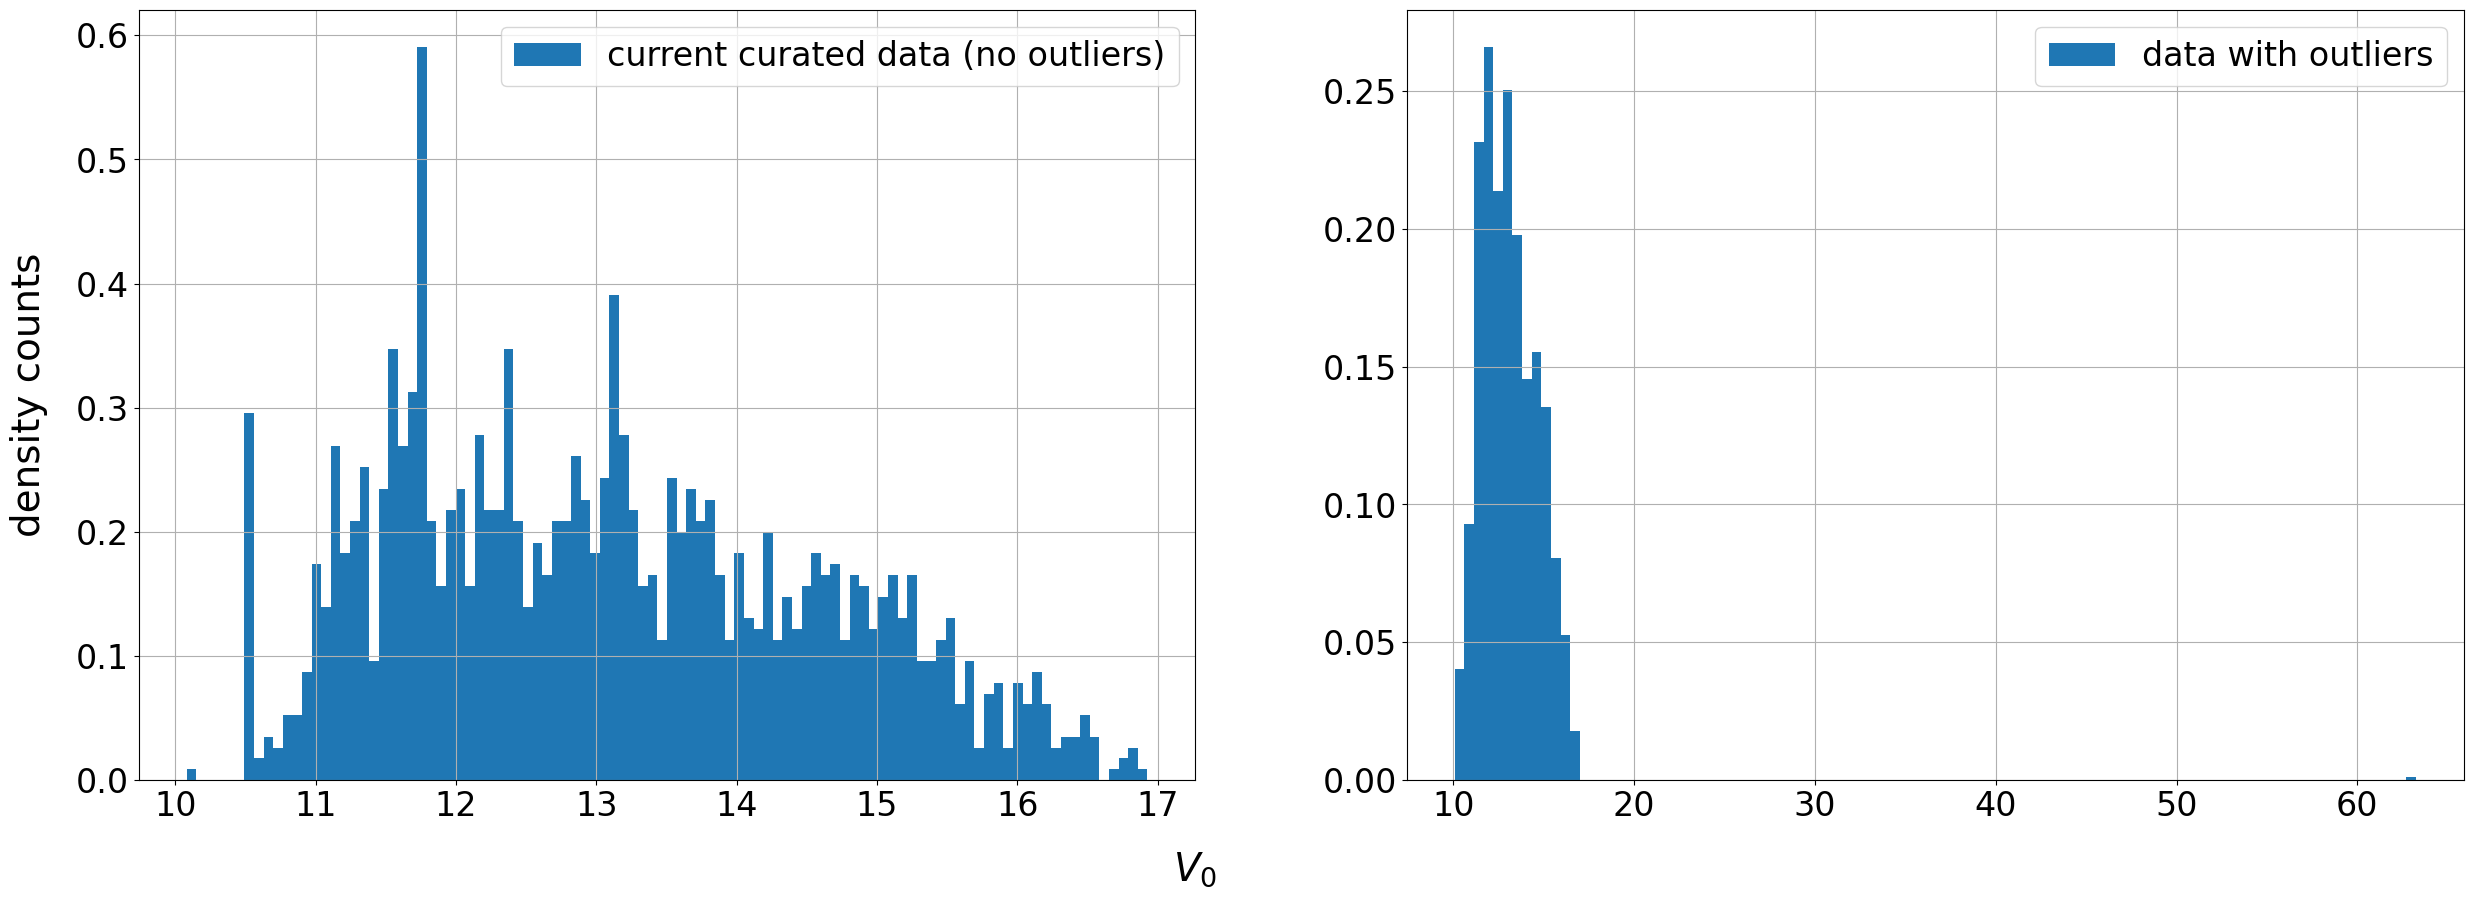

In [29]:
figV0 = Plotting.with_and_without_outliers(DATA['V0'], low=0, hig=50,title='$V_0$')

In [30]:
DATA[(DATA['V0']>50)]

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_13,NSC_bn_14,NSC_bn_15,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv10Co_pv20.sigma-ABABB.FM,-147.53199,-4.81,25.92226,-150.929333,926.084667,-5893.904667,38513.326667,-256669.066667,1.736711e+06,-11893516.0,...,0.0,0.0,0.0,-4.73451,1.928963,2.0,3.799786,63.222334,-0.263318,-8.03795


In [31]:
DATA = DATA[(DATA['V0'])>0 & (DATA['V0']<50)]

In [32]:
DATA.shape

(1682, 70)

## Drop Nans !

In [33]:
DATA.dropna(how='any', axis=0,inplace=True)

# Histograms of features

Are there more outliers ?

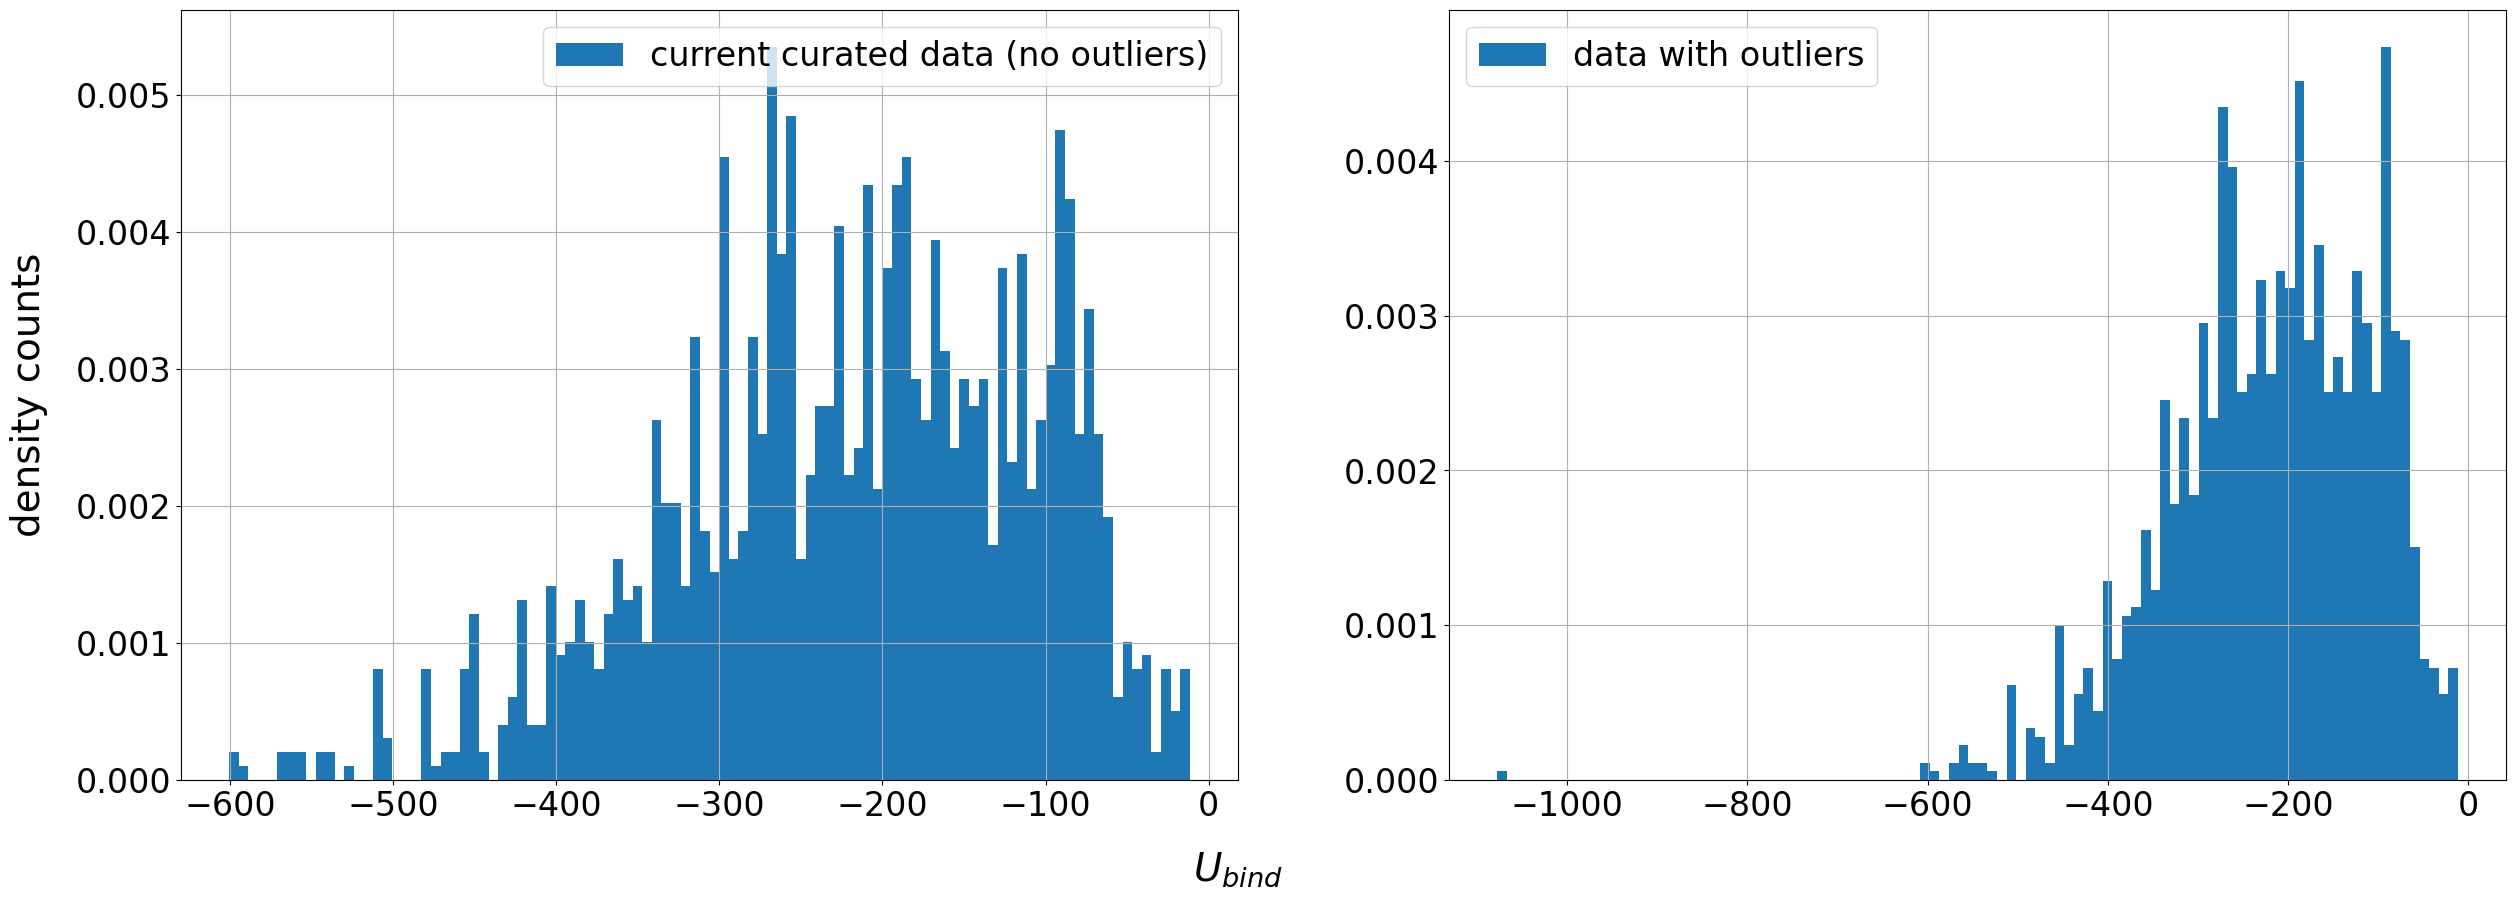

In [34]:
figUbind = Plotting.with_and_without_outliers(DATA['NSC_U_bind_0'], low=-700, hig=0,title=feature_titles[columns_U].values[0])

In [35]:
DATA[(DATA['NSC_U_bind_0'])<-700 ]

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_13,NSC_bn_14,NSC_bn_15,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
W_sv53.R.NM,-1077.572644,-5.56,54.19617,-585.763094,6884.475283,-85017.118868,1.089134e+06,-1.435203e+07,1.934946e+08,-2.658823e+09,...,0.0,0.0,0.0,-6.367196,5.435779,0.0,283.751697,16.733067,0.349466,-12.604124


In [36]:
DATA.shape

(1682, 70)

In [37]:
Plotting = SourceFileLoader('Plotting', 'Tools.py').load_module().Plotting

In [38]:
np.ceil(len(useful['an'])/5).astype(int)

4

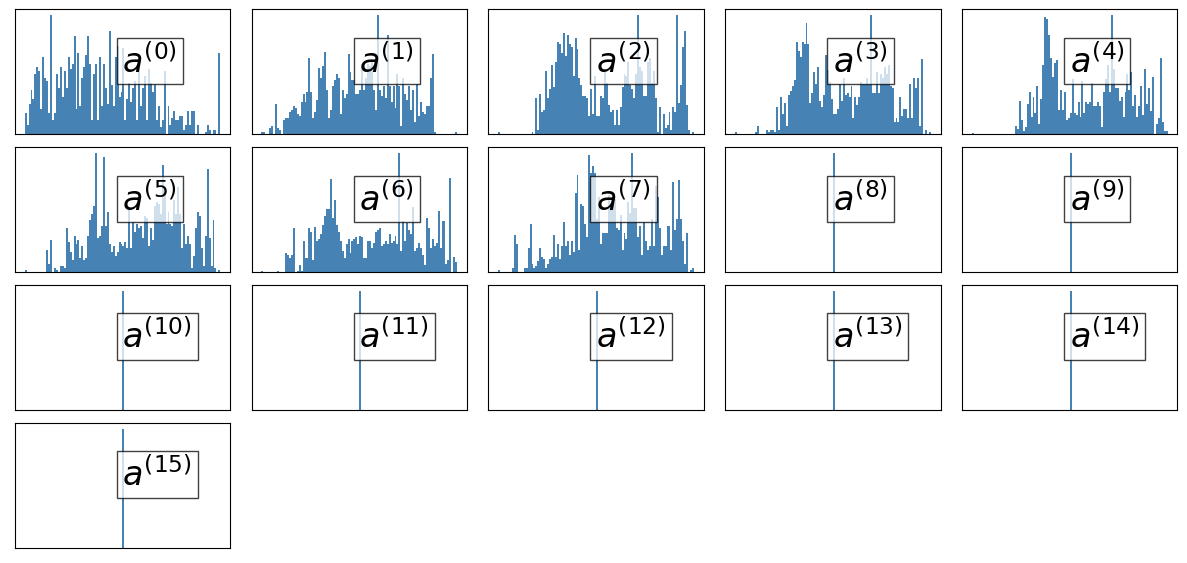

In [39]:
figure = Plotting.histoff_realfeatures(DATA,useful['an'],feature_titles[useful['an']], figsize_=(15,7))
figure.savefig(FileNames.get_plot_filename('Histogram', 'an'))

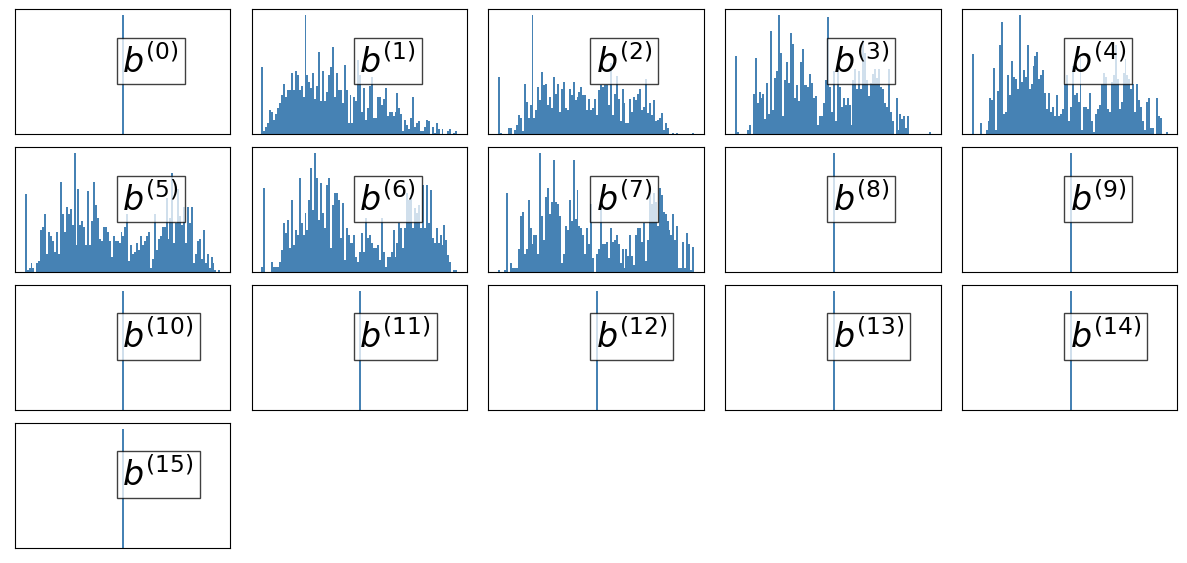

In [40]:
figure = Plotting.histoff_realfeatures(DATA,useful['bn'],feature_titles[useful['bn']],figsize_=(15,7))
figure.savefig(FileNames.get_plot_filename('Histogram','bn'))

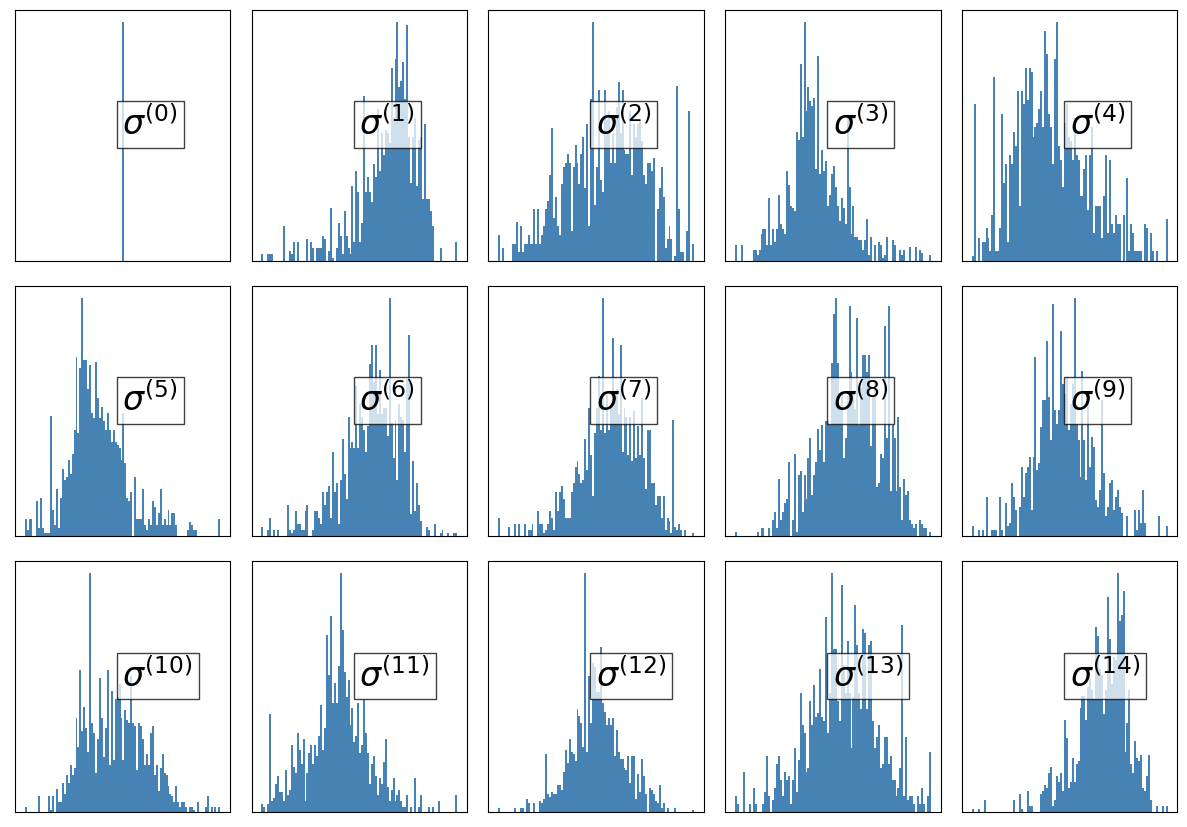

In [41]:
figure = HF.histoff_realfeatures(DATA,useful['SIGMA'],feature_titles[useful['SIGMA']],figsize_=(15,14))
figure.savefig(FileNames.get_plot_filename('Histogram','sigmas'))

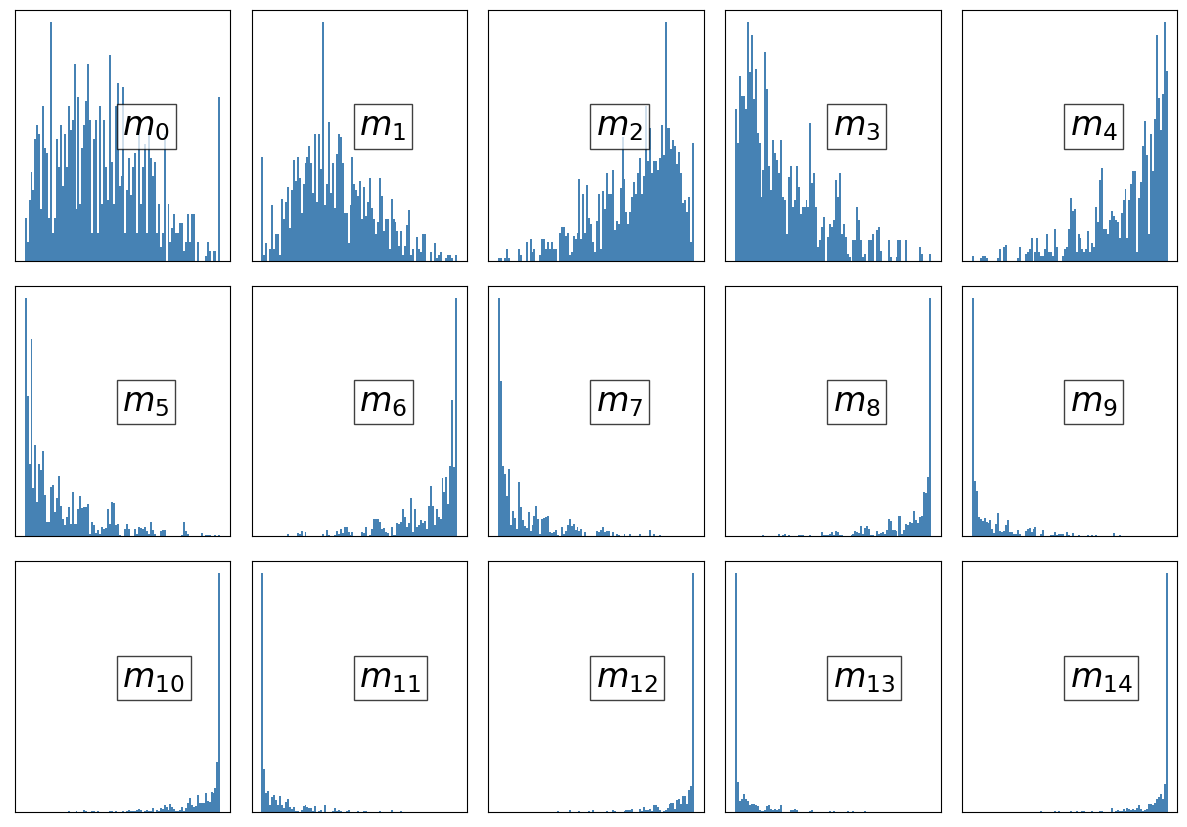

In [42]:
figure = HF.histoff_realfeatures(DATA,useful['moment'],feature_titles[useful['moment']],figsize_=(15,14))
figure.savefig(FileNames.get_plot_filename('Histogram','moments'))

In [43]:
DATA[DATA['V0']>20]

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_13,NSC_bn_14,NSC_bn_15,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv10Co_pv20.sigma-ABABB.FM,-147.53199,-4.81,25.92226,-150.929333,926.084667,-5893.904667,38513.326667,-256669.066667,1.736711e+06,-11893516.0,...,0.0,0.0,0.0,-4.73451,1.928963,2.0,3.799786,63.222334,-0.263318,-8.03795


Text(0, 0.5, '$V_0$')

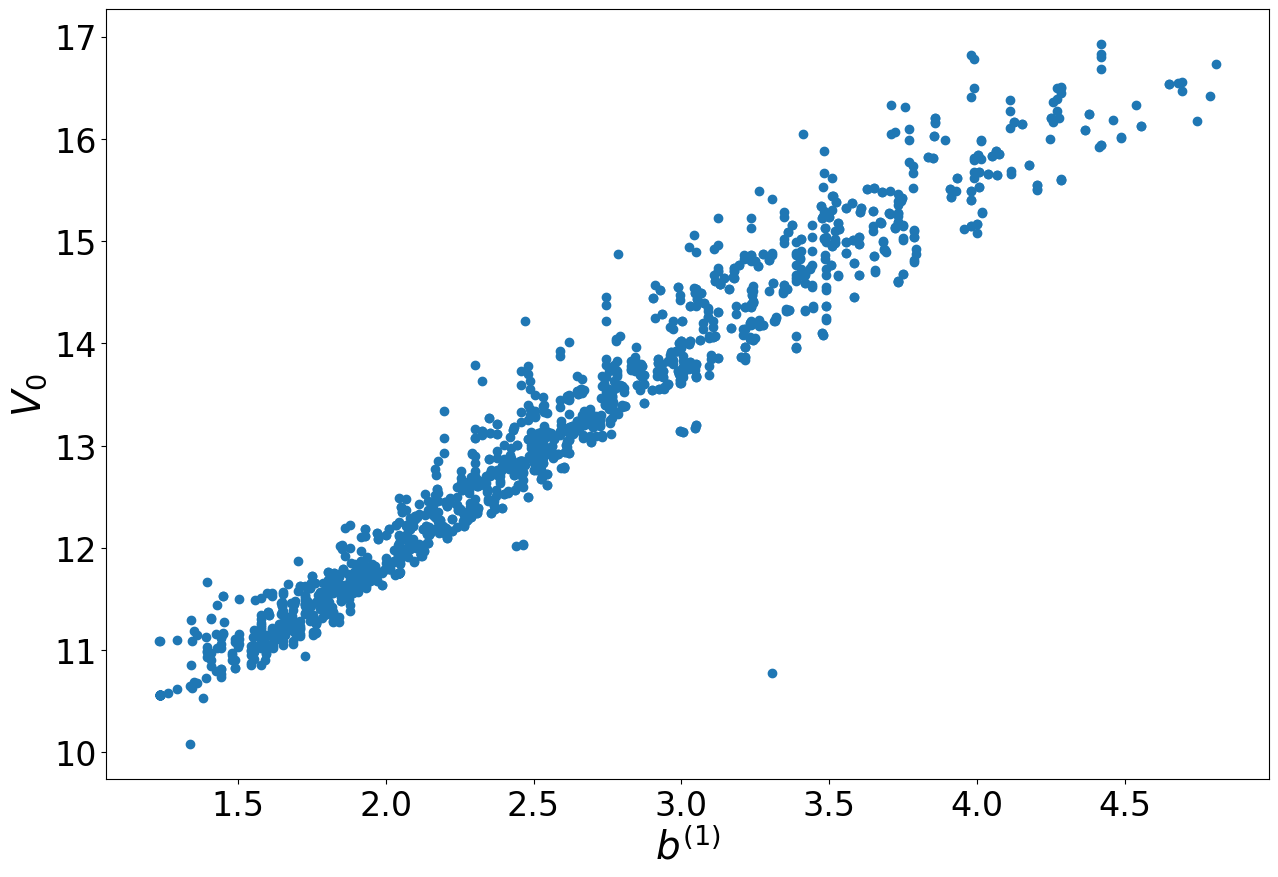

In [50]:
plt.plot(DATA['NSC_bn_1'][DATA['V0']<20],DATA['V0'][DATA['V0']<20],'o')
plt.xlabel(feature_titles['NSC_bn_1'])
plt.ylabel('$V_0$')

# all features in the same Range

to compare between different features, first I have to reduce to standard ranges because the scale is too different. 

In [51]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [52]:
SC = MinMaxScaler()
BOPSC = pd.DataFrame(SC.fit_transform(BOP[real_feature]), columns=real_feature, index=BOP.index)

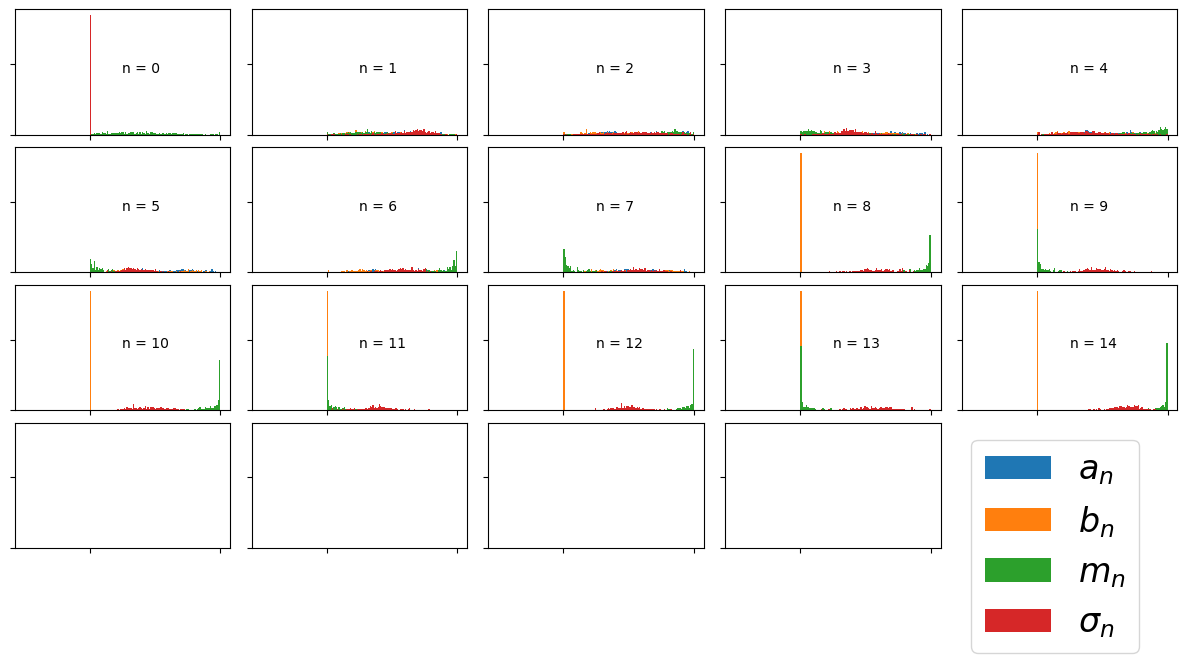

In [53]:
nrows = np.ceil(len(useful['an'])/5).astype(int)
fig, ax = plt.subplots(nrows, 5, figsize=(15,7),sharex=True,sharey=True)
for n, (thean, thebn, themn, thesn) in enumerate(zip(useful['an'], useful['bn'], useful['moment'], useful['SIGMA'])):
    thisrow = np.floor(n/5).astype(int)
    thiscol = n%5
    histan = ax[thisrow, thiscol].hist(BOPSC[thean], bins=100, label=feature_titles[thean])
    histbn = ax[thisrow, thiscol].hist(BOPSC[thebn], bins=100, label=feature_titles[thebn])
    histmu = ax[thisrow, thiscol].hist(BOPSC[themn], bins=100, label=feature_titles[themn])
    histsig = ax[thisrow, thiscol].hist(BOPSC[thesn], bins=100, label=feature_titles[thesn])
    frametag = ax[thisrow, thiscol].annotate( f'n = {n}',(0.5, 0.5), textcoords='axes fraction')
ax[-1,-1].set_xticklabels([])
ax[-1,-1].set_yticklabels([])
ax[-1,-1].remove()
h,l  = ax[0,0].get_legend_handles_labels()
ax[-1,-2].legend(h,['$a_{n}$','$b_{n}$','$m_{n}$', '$\sigma_{n}$'],  bbox_to_anchor = (2, 1))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.savefig(FileNames.get_plot_filename('CompareStandardDistributions','an_bn_mn_sigma')) 

# Classification and weighting

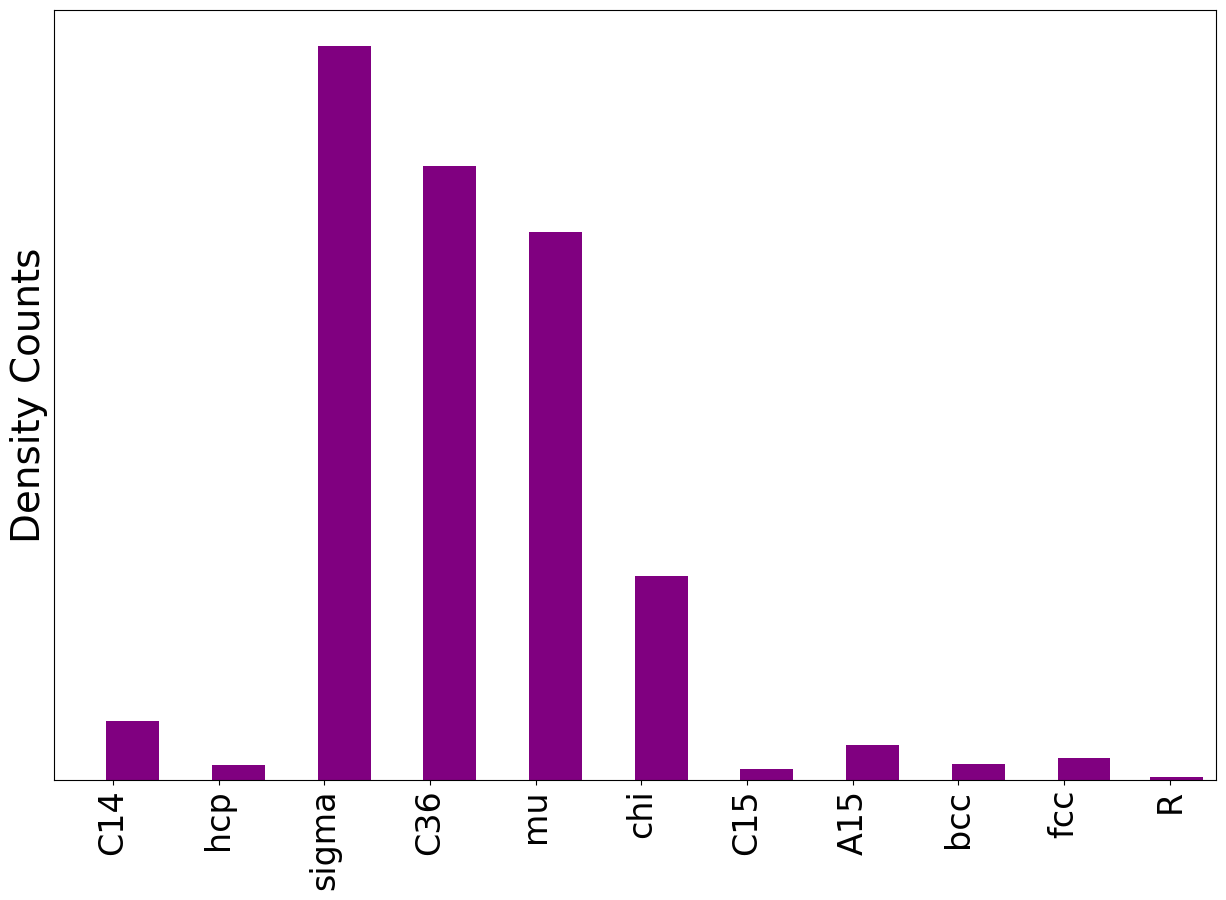

In [55]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('Density Counts')
plt.savefig('graphs/ClassCounts.pdf')